In [1]:
# Cài đặt các thư viện cần thiết
!pip install seaborn matplotlib tensorflow scikit-learn pandas numpy -q

# Import các thư viện
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Thiết lập hiển thị đẹp
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print("✅ Đã import tất cả thư viện thành công!")

✅ Đã import tất cả thư viện thành công!


In [2]:
# ==================== CÂU 1 ====================
# Tải bộ dữ liệu titanic từ seaborn
titanic = sns.load_dataset('titanic')

# 1. In ra 5 dòng đầu tiên
print("=== 5 DÒNG ĐẦU TIÊN CỦA TẬP DỮ LIỆU ===")
display(titanic.head())

# 2. In ra thông tin tổng quan
print("\n=== THÔNG TIN TỔNG QUAN ===")
titanic.info()

=== 5 DÒNG ĐẦU TIÊN CỦA TẬP DỮ LIỆU ===


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True



=== THÔNG TIN TỔNG QUAN ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [3]:
# ==================== CÂU 2 ====================

# 1. Đếm số lượng giá trị khuyết ở mỗi cột
print("=== SỐ LƯỢNG GIÁ TRỊ KHUYẾT Ở MỖI CỘT ===")
print(titanic.isnull().sum())

# 2. Xóa cột 'deck' (quá nhiều giá trị khuyết)
titanic_cleaned = titanic.drop('deck', axis=1)
print("\n=== SAU KHI XÓA CỘT 'deck' ===")
print(f"Số cột còn lại: {titanic_cleaned.shape[1]}")
print(f"Các cột hiện có: {list(titanic_cleaned.columns)}")

# 3. Điền giá trị khuyết của cột 'age' bằng Mean
age_mean = titanic_cleaned['age'].mean()
titanic_cleaned['age'] = titanic_cleaned['age'].fillna(age_mean)

print(f"\n=== SAU KHI ĐIỀN GIÁ TRỊ KHUYẾT CHO 'age' ===")
print(f"Giá trị trung bình của tuổi: {age_mean:.2f}")
print(f"Số giá trị khuyết còn lại ở cột 'age': {titanic_cleaned['age'].isnull().sum()}")
print(f"5 giá trị đầu của cột 'age': {titanic_cleaned['age'].head().tolist()}")

=== SỐ LƯỢNG GIÁ TRỊ KHUYẾT Ở MỖI CỘT ===
survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

=== SAU KHI XÓA CỘT 'deck' ===
Số cột còn lại: 14
Các cột hiện có: ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'embark_town', 'alive', 'alone']

=== SAU KHI ĐIỀN GIÁ TRỊ KHUYẾT CHO 'age' ===
Giá trị trung bình của tuổi: 29.70
Số giá trị khuyết còn lại ở cột 'age': 0
5 giá trị đầu của cột 'age': [22.0, 38.0, 26.0, 35.0, 35.0]


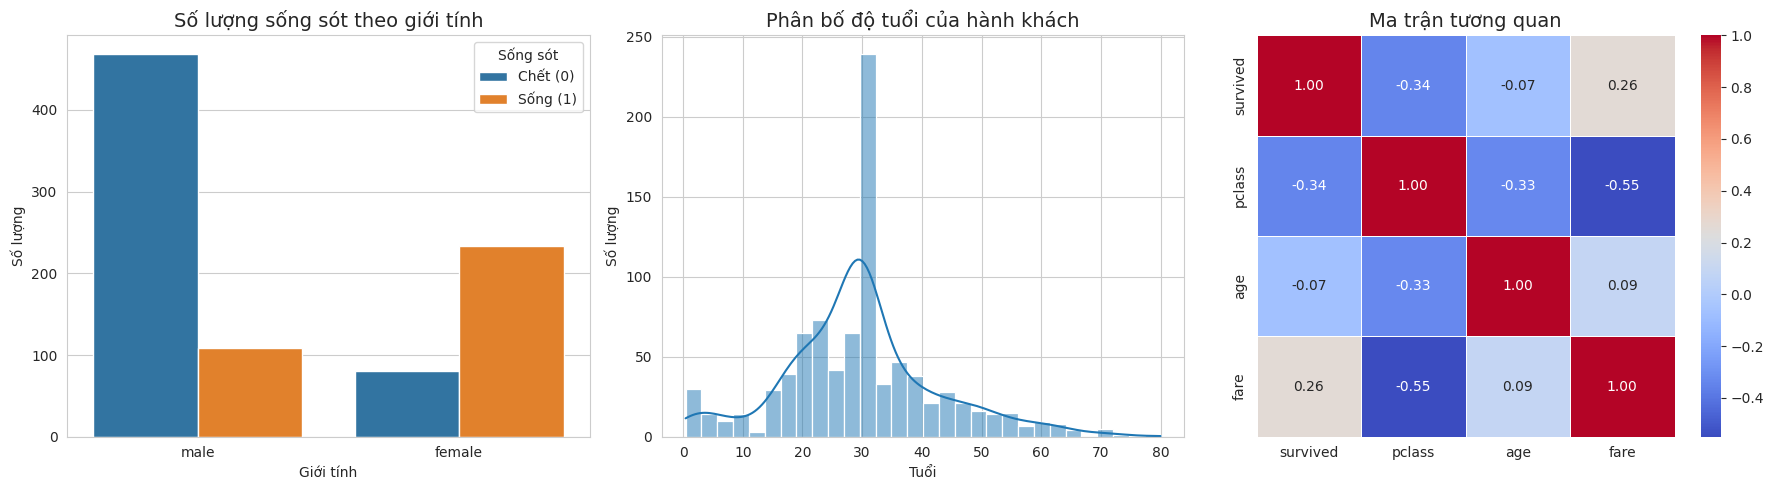


=== MA TRẬN TƯƠNG QUAN ===
          survived    pclass       age      fare
survived  1.000000 -0.338481 -0.069809  0.257307
pclass   -0.338481  1.000000 -0.331339 -0.549500
age      -0.069809 -0.331339  1.000000  0.091566
fare      0.257307 -0.549500  0.091566  1.000000


In [4]:
# ==================== CÂU 3 ====================

# Tạo figure với 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Biểu đồ cột: Số lượng sống sót theo giới tính
sns.countplot(data=titanic_cleaned, x='sex', hue='survived', ax=axes[0])
axes[0].set_title('Số lượng sống sót theo giới tính', fontsize=14)
axes[0].set_xlabel('Giới tính')
axes[0].set_ylabel('Số lượng')
axes[0].legend(title='Sống sót', labels=['Chết (0)', 'Sống (1)'])

# 2. Biểu đồ phân bố độ tuổi
sns.histplot(data=titanic_cleaned, x='age', bins=30, kde=True, ax=axes[1])
axes[1].set_title('Phân bố độ tuổi của hành khách', fontsize=14)
axes[1].set_xlabel('Tuổi')
axes[1].set_ylabel('Số lượng')

# 3. Ma trận tương quan và Heatmap
# Lọc các cột số
numeric_cols = ['survived', 'pclass', 'age', 'fare']
correlation_matrix = titanic_cleaned[numeric_cols].corr()

# Vẽ heatmap
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f',
            linewidths=0.5, ax=axes[2])
axes[2].set_title('Ma trận tương quan', fontsize=14)

plt.tight_layout()
plt.show()

# In ma trận tương quan
print("\n=== MA TRẬN TƯƠNG QUAN ===")
print(correlation_matrix)

In [5]:
# ==================== CÂU 4 ====================

# Tạo bản sao để không ảnh hưởng dữ liệu gốc
titanic_encoded = titanic_cleaned.copy()

# 1. Label Encoding cho cột 'sex'
sex_mapping = {'male': 0, 'female': 1}
titanic_encoded['sex'] = titanic_encoded['sex'].map(sex_mapping)

print("=== SAU LABEL ENCODING CỘT 'sex' ===")
print(titanic_encoded[['sex']].head(10))
print(f"\nGiá trị duy nhất trong cột 'sex': {titanic_encoded['sex'].unique()}")
print(f"Phân phối: {titanic_encoded['sex'].value_counts().to_dict()}")

# 2. One-Hot Encoding cho cột 'embarked'
embarked_dummies = pd.get_dummies(titanic_encoded['embarked'], prefix='embarked', dtype=int)
titanic_encoded = pd.concat([titanic_encoded, embarked_dummies], axis=1)

print("\n=== SAU ONE-HOT ENCODING CỘT 'embarked' ===")
print(titanic_encoded[['embarked'] + list(embarked_dummies.columns)].head(10))
print(f"\nSố cột mới được thêm vào: {len(embarked_dummies.columns)}")
print(f"Tổng số cột hiện tại: {titanic_encoded.shape[1]}")

=== SAU LABEL ENCODING CỘT 'sex' ===
   sex
0    0
1    1
2    1
3    1
4    0
5    0
6    0
7    0
8    1
9    1

Giá trị duy nhất trong cột 'sex': [0 1]
Phân phối: {0: 577, 1: 314}

=== SAU ONE-HOT ENCODING CỘT 'embarked' ===
  embarked  embarked_C  embarked_Q  embarked_S
0        S           0           0           1
1        C           1           0           0
2        S           0           0           1
3        S           0           0           1
4        S           0           0           1
5        Q           0           1           0
6        S           0           0           1
7        S           0           0           1
8        S           0           0           1
9        C           1           0           0

Số cột mới được thêm vào: 3
Tổng số cột hiện tại: 17


In [6]:
# ==================== CÂU 5 ====================

# 1. Tạo X và y (sử dụng dữ liệu đã mã hóa)
X = titanic_encoded[['pclass', 'sex', 'age']]
y = titanic_encoded['survived']

print("=== ĐẶC TRƯNG (X) ===")
print(X.head())
print(f"\nKích thước X: {X.shape}")
print(f"Kích thước y: {y.shape}")
print(f"\nPhân phối của y (sống sót):")
print(y.value_counts().to_dict())

# 2. Chia dữ liệu thành train/test (80%-20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"\n=== KẾT QUẢ CHIA DỮ LIỆU ===")
print(f"Tập train: X_train={X_train.shape}, y_train={y_train.shape}")
print(f"Tập test: X_test={X_test.shape}, y_test={y_test.shape}")
print(f"Tỷ lệ train/test: {len(X_train)/(len(X_train)+len(X_test)):.0%} / {len(X_test)/(len(X_train)+len(X_test)):.0%}")

# 3. Chuẩn hóa dữ liệu bằng StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\n=== SAU KHI CHUẨN HÓA ===")
print(f"Mean của X_train: {X_train_scaled.mean(axis=0)}")
print(f"Std của X_train: {X_train_scaled.std(axis=0)}")
print(f"\n5 mẫu đầu tiên của X_train đã chuẩn hóa:")
print(X_train_scaled[:5])

=== ĐẶC TRƯNG (X) ===
   pclass  sex   age
0       3    0  22.0
1       1    1  38.0
2       3    1  26.0
3       1    1  35.0
4       3    0  35.0

Kích thước X: (891, 3)
Kích thước y: (891,)

Phân phối của y (sống sót):
{0: 549, 1: 342}

=== KẾT QUẢ CHIA DỮ LIỆU ===
Tập train: X_train=(712, 3), y_train=(712,)
Tập test: X_test=(179, 3), y_test=(179,)
Tỷ lệ train/test: 80% / 20%

=== SAU KHI CHUẨN HÓA ===
Mean của X_train: [9.35581201e-17 9.97953281e-18 1.12269744e-17]
Std của X_train: [1. 1. 1.]

5 mẫu đầu tiên của X_train đã chuẩn hóa:
[[-1.61413602 -0.7243102   1.22920747]
 [-0.40055118 -0.7243102  -0.50350514]
 [ 0.81303367 -0.7243102   0.18957991]
 [ 0.81303367 -0.7243102  -0.27247679]
 [ 0.81303367  1.38062393 -1.81266577]]


=== TÓM TẮT MÔ HÌNH ===


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 81 (324.00 B)

 Trainable params: 81 (324.00 B)

 Non-trainable params: 0 (0.00 B)


=== TIẾN HÀNH HUẤN LUYỆN MÔ HÌNH ===
Epoch 1/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 4s 39ms/step - accuracy: 0.4888 - loss: 0.7606 - val_accuracy: 0.5754 - val_loss: 0.7512
Epoch 2/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.6222 - loss: 0.7182 - val_accuracy: 0.5866 - val_loss: 0.7139
Epoch 3/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6236 - loss: 0.6836 - val_accuracy: 0.5866 - val_loss: 0.6827
Epoch 4/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6236 - loss: 0.6534 - val_accuracy: 0.5866 - val_loss: 0.6544
Epoch 5/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.6236 - loss: 0.6261 - val_accuracy: 0.5866 - val_loss: 0.6289
Epoch 6/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.6250 - loss: 0.6017 - val_accuracy: 0.5922 - val_loss: 0.6059
Epoch 7/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.7093 - loss: 0.5799 - val_accuracy: 0.7151 - val_loss: 0.5857
Epoch 8/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.7654 - l

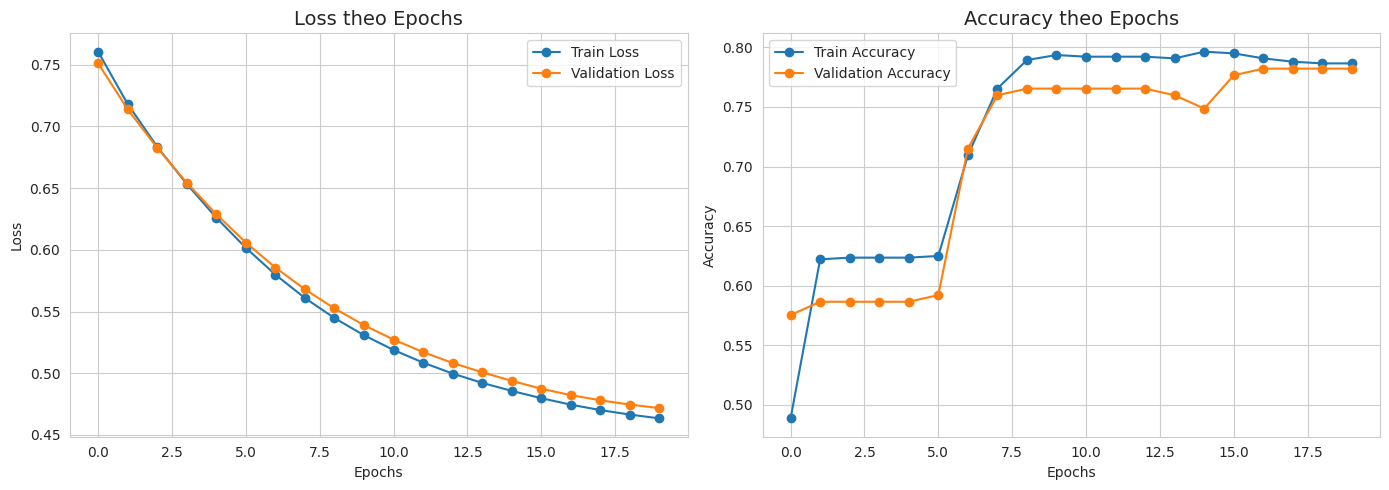


=== DỰ ĐOÁN MẪU TỪ TẬP TEST ===
Mẫu 0: Dự đoán = 0 (xác suất: 0.1131), Thực tế = 1
Mẫu 5: Dự đoán = 1 (xác suất: 0.7935), Thực tế = 1
Mẫu 10: Dự đoán = 0 (xác suất: 0.3277), Thực tế = 0
Mẫu 15: Dự đoán = 1 (xác suất: 0.7662), Thực tế = 1
Mẫu 20: Dự đoán = 0 (xác suất: 0.1404), Thực tế = 0


In [7]:
# ==================== CÂU 6 ====================

# Đặt seed để kết quả reproducible
tf.random.set_seed(42)
np.random.seed(42)

# 1. Khởi tạo mô hình Sequential
model = keras.Sequential()

# 2. Thêm lớp ẩn với 16 neuron, activation='relu'
model.add(layers.Dense(16, activation='relu', input_shape=(3,)))

# 3. Thêm lớp đầu ra với 1 neuron, activation='sigmoid'
model.add(layers.Dense(1, activation='sigmoid'))

# 4. Compile mô hình
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

# Hiển thị tóm tắt mô hình
print("=== TÓM TẮT MÔ HÌNH ===")
model.summary()

# 5. Huấn luyện mô hình
print("\n=== TIẾN HÀNH HUẤN LUYỆN MÔ HÌNH ===")
history = model.fit(X_train_scaled, y_train,
                    epochs=20,
                    batch_size=32,
                    validation_data=(X_test_scaled, y_test),
                    verbose=1)

# Đánh giá trên tập test
print("\n=== ĐÁNH GIÁ MÔ HÌNH TRÊN TẬP TEST ===")
test_loss, test_accuracy = model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"Loss trên tập test: {test_loss:.4f}")
print(f"Accuracy trên tập test: {test_accuracy:.4f}")

# Vẽ biểu đồ quá trình huấn luyện
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Biểu đồ Loss
axes[0].plot(history.history['loss'], label='Train Loss', marker='o')
axes[0].plot(history.history['val_loss'], label='Validation Loss', marker='o')
axes[0].set_title('Loss theo Epochs', fontsize=14)
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

# Biểu đồ Accuracy
axes[1].plot(history.history['accuracy'], label='Train Accuracy', marker='o')
axes[1].plot(history.history['val_accuracy'], label='Validation Accuracy', marker='o')
axes[1].set_title('Accuracy theo Epochs', fontsize=14)
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

# Dự đoán một vài mẫu từ tập test
print("\n=== DỰ ĐOÁN MẪU TỪ TẬP TEST ===")
sample_indices = [0, 5, 10, 15, 20]
for idx in sample_indices:
    if idx < len(X_test_scaled):
        pred = model.predict(X_test_scaled[idx:idx+1], verbose=0)
        pred_class = 1 if pred[0][0] > 0.5 else 0
        print(f"Mẫu {idx}: Dự đoán = {pred_class} (xác suất: {pred[0][0]:.4f}), Thực tế = {y_test.iloc[idx]}")